Exercices XP Ninja

Exercice 1 : Airbnb New York

Aperçu :


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



Taille : 48895 lignes x 16 colonnes

Valeurs manquantes :
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Valeurs manquantes après traitement :
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                         

,price,booking_rate,price_per_person
0,149.0,0.024590,74.500000
1,225.0,0.126404,112.500000
2,150.0,0.000000,37.500000
3,89.0,0.300000,44.500000
4,80.0,9.000000,7.272727


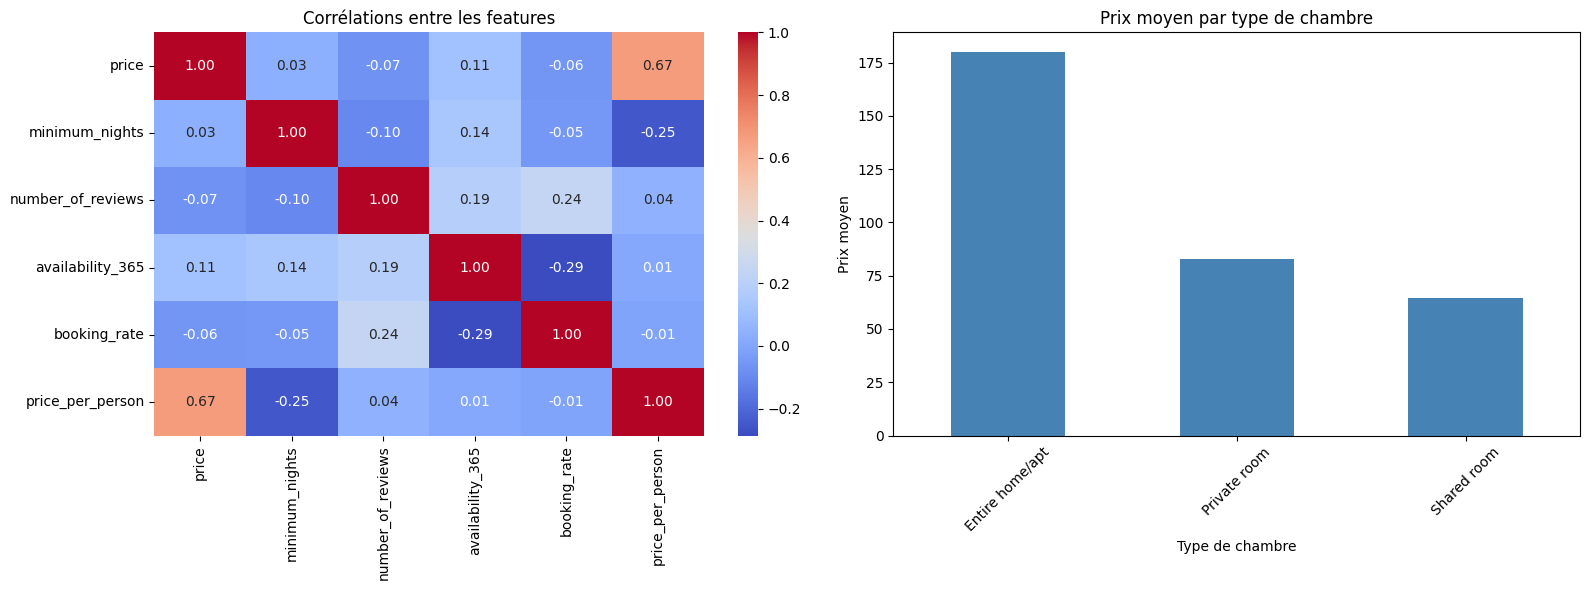

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer

# chargement du dataset Airbnb
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/New%20York%20City%20Airbnb%20Open%20Data.zip"

response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))
df = pd.read_csv(z.open(z.namelist()[0]), encoding='latin-1')

print("Aperçu :")
display(df.head())
print(f"\nTaille : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print("\nValeurs manquantes :")
print(df.isnull().sum())


# traitement des valeurs manquantes avec KNNImputer pour les colonnes numériques
# KNN impute en cherchant les voisins les plus proches, plus précis que la moyenne
colonnes_numeriques = ['price', 'minimum_nights', 'number_of_reviews',
                       'reviews_per_month', 'availability_365']

imputer = KNNImputer(n_neighbors=5)
df[colonnes_numeriques] = imputer.fit_transform(df[colonnes_numeriques])

# pour les colonnes texte on remplace par 'Unknown'
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')
df['last_review'] = df['last_review'].fillna('No review')

print("\nValeurs manquantes après traitement :")
print(df.isnull().sum())


# traitement des valeurs aberrantes sur price et number_of_reviews
for col in ['price', 'number_of_reviews']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(
        lower=Q1 - 1.5 * IQR,
        upper=Q3 + 1.5 * IQR
    )


# création de nouvelles features
# taux de réservation = nombre d'avis / disponibilité
# on ajoute 1 pour éviter la division par zéro
df['booking_rate'] = df['number_of_reviews'] / (df['availability_365'] + 1)

# prix par personne en se basant sur minimum_nights comme proxy
df['price_per_person'] = df['price'] / (df['minimum_nights'] + 1)

print("\nNouvelles features créées :")
display(df[['price', 'booking_rate', 'price_per_person']].head())


# analyse exploratoire - corrélations avec le prix
colonnes_corr = ['price', 'minimum_nights', 'number_of_reviews',
                 'availability_365', 'booking_rate', 'price_per_person']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# heatmap des corrélations
corr = df[colonnes_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title("Corrélations entre les features")

# distribution des prix par type de chambre
df.groupby('room_type')['price'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title("Prix moyen par type de chambre")
axes[1].set_xlabel("Type de chambre")
axes[1].set_ylabel("Prix moyen")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Exercice 2 : Bonheur Mondial + Santé

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# chargement des deux datasets
url_bonheur = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/World%20Happiness%20Report%20Dataset.zip"
url_sante = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/Global%20Health%20and%20Population%20Stats.zip"

response1 = requests.get(url_bonheur)
z1 = zipfile.ZipFile(io.BytesIO(response1.content))
df_bonheur = pd.read_csv(z1.open(z1.namelist()[0]), encoding='latin-1')

response2 = requests.get(url_sante)
z2 = zipfile.ZipFile(io.BytesIO(response2.content))
df_sante = pd.read_csv(z2.open(z2.namelist()[0]), encoding='latin-1')

print("Colonnes Bonheur :", df_bonheur.columns.tolist())
print("Colonnes Santé :", df_sante.columns.tolist())

# fusion des deux datasets sur la colonne pays
# on cherche la colonne commune entre les deux datasets
df_merge = pd.merge(df_bonheur, df_sante, on='Country', how='inner')
print(f"\nTaille après fusion : {df_merge.shape}")

# normalisation des colonnes numériques
colonnes_a_normaliser = df_merge.select_dtypes(include=['float64', 'int64']).columns.tolist()

scaler = StandardScaler()
df_normalise = df_merge.copy()
df_normalise[colonnes_a_normaliser] = scaler.fit_transform(df_merge[colonnes_a_normaliser])

# comparaison avant / après normalisation
print("\nAvant normalisation :")
print(df_merge[colonnes_a_normaliser].describe().round(2))
print("\nAprès normalisation :")
print(df_normalise[colonnes_a_normaliser].describe().round(2))

# ACP pour réduire la dimensionnalité
df_pca_input = df_normalise[colonnes_a_normaliser].dropna()

pca = PCA(n_components=2)
composantes = pca.fit_transform(df_pca_input)
df_pca_result = pd.DataFrame(composantes, columns=['PC1', 'PC2'])

print(f"\nVariance expliquée par les 2 composantes : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# visualisation ACP
plt.figure(figsize=(8, 6))
plt.scatter(df_pca_result['PC1'], df_pca_result['PC2'], alpha=0.5, color='steelblue')
plt.title("ACP - Réduction à 2 dimensions")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.show()

Colonnes Bonheur : ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
Colonnes Santé : ['ï»¿Location', 'Period', 'Indicator', 'Dim1', 'First Tooltip']


KeyError: 'Country'

Exercice 3 : Réduction de dimensionnalité

In [3]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# chargement du dataset clients
url_shop = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/blob/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20%26%20T/Shop%20Customer%20Dataset.zip"

response = requests.get(url_shop)
z = zipfile.ZipFile(io.BytesIO(response.content))
df_shop = pd.read_csv(z.open(z.namelist()[0]), encoding='latin-1')

print("Colonnes :", df_shop.columns.tolist())
display(df_shop.head())

# on garde uniquement les colonnes numériques
colonnes_num = df_shop.select_dtypes(include=['float64', 'int64']).columns.tolist()
df_num = df_shop[colonnes_num].dropna()

# normalisation avant ACP et t-SNE
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)


# ACP avec différents nombres de composantes
print("\nVariance expliquée selon le nombre de composantes :")
for n in range(1, len(colonnes_num) + 1):
    pca = PCA(n_components=n)
    pca.fit(df_scaled)
    variance = pca.explained_variance_ratio_.sum() * 100
    print(f"{n} composante(s) : {variance:.1f}% de variance conservée")

# ACP à 2 composantes pour visualisation
pca_2 = PCA(n_components=2)
pca_result = pca_2.fit_transform(df_scaled)

# t-SNE à 2 composantes pour comparaison
# t-SNE est meilleur pour visualiser des clusters
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(df_scaled)


# visualisation côte à côte ACP vs t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, color='steelblue')
axes[0].set_title(f"ACP - {pca_2.explained_variance_ratio_.sum()*100:.1f}% variance conservée")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.5, color='orange')
axes[1].set_title("t-SNE")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

plt.tight_layout()
plt.show()


# analyse comparative
print("""
ANALYSE COMPARATIVE ACP vs t-SNE :

ACP :
- Conserve la variance maximale des données
- Rapide à calculer
- Utile pour comprendre quelles variables expliquent le plus les données
- Résultat : {:.1f}% de variance conservée avec 2 composantes

t-SNE :
- Meilleur pour visualiser des groupes (clusters) dans les données
- Plus lent que l'ACP
- Ne conserve pas la variance mais préserve les relations locales entre points
- Utile pour voir si les clients se regroupent naturellement

Conclusion :
Si on veut réduire les données pour un modèle : ACP
Si on veut visualiser des groupes : t-SNE
""".format(pca_2.explained_variance_ratio_.sum()*100))

BadZipFile: File is not a zip file

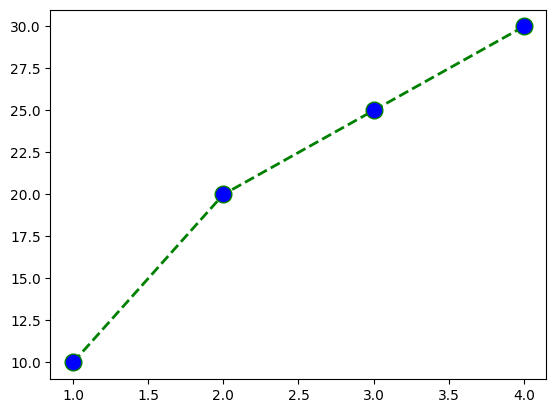

In [2]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4]
y = [10, 20, 25, 30]

plt.plot(x, y, color='green', linestyle='dashed', linewidth=2, marker='o', markerfacecolor='blue', markersize=12)
plt.show()